In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
%matplotlib inline

df = pd.read_csv("titanic (2)/titanic.csv")
print(f"Original df Shape {df.shape}")
df.head()

Original df Shape (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"Total missing values is {df.isnull().sum().sum()}")

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Total missing values is 866


In [3]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
print("Survival rate by Cabin:")

print(df.groupby("HasCabin")['Survived'].mean())


Survival rate by Cabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [4]:
df = df.drop(columns='Cabin')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [6]:
print("Median Age by Pclass and Sex:")
print(df.groupby(['Pclass', 'Sex'])['Age'].median())

print(f"Missing value before inputation : {df['Age'].isnull().sum().sum()}")

Median Age by Pclass and Sex:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64
Missing value before inputation : 177


In [7]:
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

df['Age'] = df['Age'].fillna(df['Age'].median())

print(f"Missing value After inputation : {df['Age'].isnull().sum().sum()}")

Missing value After inputation : 0


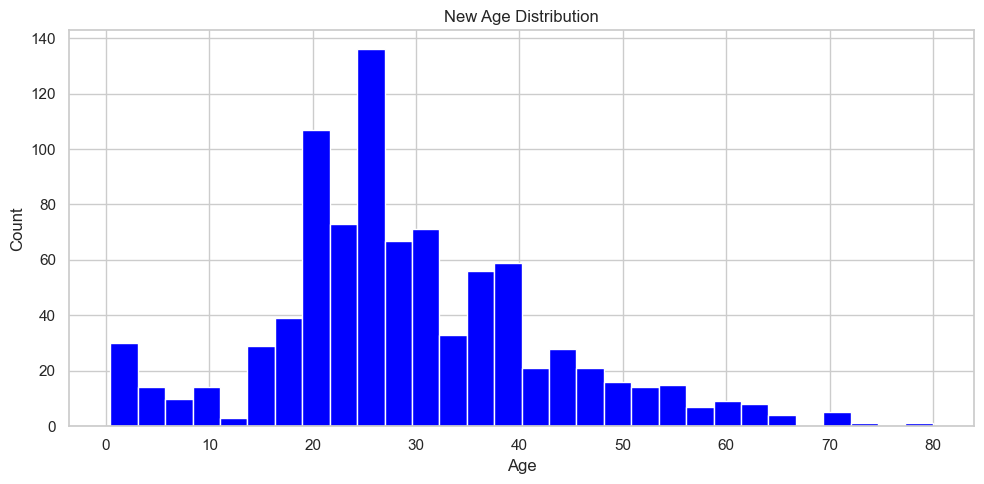

In [8]:
fig, ax=plt.subplots(figsize=(10, 5))

ax.hist(df['Age'], bins= 30, edgecolor='white', color='blue')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title("New Age Distribution")

plt.tight_layout()
plt.show()

In [9]:
print(f"Missing Embarked values: {df['Embarked'].isnull().sum()}")
print(f"Mode of Embarked: {df['Embarked'].mode()[0]}")

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(f"Missing Embarked after filling: {df['Embarked'].isnull().sum()}")

Missing Embarked values: 2
Mode of Embarked: S
Missing Embarked after filling: 0


In [10]:
print("Missing Values After Cleaning:")

print(df.isnull().sum())
print(f"Total Misssing Values After Cleaning: {df.isnull().sum().sum()}")

Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64
Total Misssing Values After Cleaning: 0


In [11]:
df['Title'] = df['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())

print("Title count")
print(df['Title'].value_counts())

Title count
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64


In [12]:
title_mapping ={
    'Mr':'Mr',
    'Miss':'Miss',
    'Mrs':'Mrs',
    'Master':'Master',
}

df['Title'] = df['Title'].apply(lambda x: title_mapping.get(x, 'Rare'))

print("Title Count after grouping: ")
print(df['Title'].value_counts())

print("\n")

print("Survival Rate by Title: ")
print(df.groupby('Title')['Survived'].mean().sort_values(ascending=False))


Title Count after grouping: 
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


Survival Rate by Title: 
Title
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64


In [13]:
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(f"Solo Travelers: {df['IsAlone'].sum()} ({df['IsAlone'].mean():.2%})")
print(f"Survival Rate  --- Alone: {df[df["IsAlone"] == 1]['Survived'].mean():.2%}")
print(f"Survival Rate  --- With Family: {df[df["IsAlone"] == 0]['Survived'].mean():.2%}")

Solo Travelers: 537 (60.27%)
Survival Rate  --- Alone: 30.35%
Survival Rate  --- With Family: 50.56%


In [14]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0, 12, 18, 35,60, 80],
                       labels = ['Child','Teen', 'Young Adult','Adult', 'Senior'],)

print("Age Distribution: ")
print(df['AgeGroup'].value_counts().sort_index())
print('\n')
print("Survival Rate by Age Group: ")
print(f'{df.groupby('AgeGroup')['Survived'].mean()}')

Age Distribution: 
AgeGroup
Child           69
Teen            70
Young Adult    514
Adult          216
Senior          22
Name: count, dtype: int64


Survival Rate by Age Group: 
AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.357977
Adult          0.384259
Senior         0.227273
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_11848\355982653.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f'{df.groupby('AgeGroup')['Survived'].mean()}')


In [15]:
df['FareBin'] = pd.qcut(
    df['Fare'],
    q=4, 
    labels=['Low', 'Medium', 'High', 'Very High'],
)

print("Survival Rate by FareBin: ")
print(df.groupby("FareBin")['Survived'].mean())

Survival Rate by FareBin: 
FareBin
Low          0.197309
Medium       0.303571
High         0.454955
Very High    0.581081
Name: Survived, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_11848\1669505232.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("FareBin")['Survived'].mean())


In [16]:
print("Current Columns and their types:")
print(df.dtypes)
print(f"Rows - {df.shape[0]}, Columns - {df.shape[1]}")

Current Columns and their types:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
HasCabin          int64
Title            object
FamilySize        int64
IsAlone           int64
AgeGroup       category
FareBin        category
dtype: object
Rows - 891, Columns - 17


In [17]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,HasCabin,Title,FamilySize,IsAlone,AgeGroup,FareBin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Mr,2,0,Young Adult,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Mrs,2,0,Adult,Very High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss,1,1,Young Adult,Medium
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Mrs,2,0,Young Adult,Very High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Mr,1,1,Young Adult,Medium


In [18]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df= pd.get_dummies(df, 
                columns= ['Embarked', 'Title', 'AgeGroup','FareBin'],
                drop_first=True,
                dtype=int)
print(f'Shape after encoding {df.shape}')
df.head()

Shape after encoding (891, 26)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,...,1,0,0,0,1,0,0,0,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,...,0,1,0,0,0,1,0,0,0,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,...,0,0,0,0,1,0,0,1,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,...,0,1,0,0,1,0,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,...,1,0,0,0,1,0,0,1,0,0


In [19]:
df = df.drop(columns=['PassengerId','Name','Ticket'])

print(f"Final shape {df.shape}")
print("Final Columns:")
print(df.columns.tolist())

Final shape (891, 23)
Final Columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'AgeGroup_Teen', 'AgeGroup_Young Adult', 'AgeGroup_Adult', 'AgeGroup_Senior', 'FareBin_Medium', 'FareBin_High', 'FareBin_Very High']


In [20]:
print("Missing values: ")
print(df.isnull().sum().sum())
df.dtypes

Missing values: 
0


Survived                  int64
Pclass                    int64
Sex                       int64
Age                     float64
SibSp                     int64
Parch                     int64
Fare                    float64
HasCabin                  int64
FamilySize                int64
IsAlone                   int64
Embarked_Q                int64
Embarked_S                int64
Title_Miss                int64
Title_Mr                  int64
Title_Mrs                 int64
Title_Rare                int64
AgeGroup_Teen             int64
AgeGroup_Young Adult      int64
AgeGroup_Adult            int64
AgeGroup_Senior           int64
FareBin_Medium            int64
FareBin_High              int64
FareBin_Very High         int64
dtype: object

In [21]:
#SAVE THE CLEAN DATA
df.to_csv('titanic (2)/train_cleaned.csv', index=False)
print("Successfull 🥂")
print(df.shape)
df.head()


Successfull 🥂
(891, 23)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,...,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior,FareBin_Medium,FareBin_High,FareBin_Very High
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,1,0,0,0,1,0,0,0,0,0
1,1,1,1,38.0,1,0,71.2833,1,2,0,...,0,1,0,0,0,1,0,0,0,1
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,1,0,0,1,0,0
3,1,1,1,35.0,1,0,53.1000,1,2,0,...,0,1,0,0,1,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,1,0,0,0,1,0,0,1,0,0
